In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de Datos con Matplotlib y Seaborn

### Matplotlib vs Seaborn

**Matplotlib**: Biblioteca base de Python para visualización. Ofrece control total pero requiere más código.

**Seaborn**: Construido sobre matplotlib. Más fácil de usar, estilos atractivos por defecto, integrado con pandas.

In [44]:
# Configuración inicial
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

np.random.seed(42)

# Dataset 1: Ventas por mes
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
ventas = [120, 135, 148, 167, 189, 201, 195, 210, 185, 172, 158, 180]

# Dataset 2: Datos de empleados
n_empleados = 200
empleados = pd.DataFrame({
    'edad': np.random.normal(35, 10, n_empleados),
    'salario': np.random.normal(50000, 15000, n_empleados),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'RRHH'], n_empleados),
    'experiencia': np.random.randint(0, 20, n_empleados)
})

# Dataset 3: Datos de productos
productos = pd.DataFrame({
    'producto': ['A', 'B', 'C', 'D', 'E'],
    'ventas_q1': [23, 45, 56, 78, 32],
    'ventas_q2': [34, 52, 61, 85, 28],
    'ventas_q3': [28, 48, 59, 82, 35],
    'ventas_q4': [31, 55, 64, 88, 38]
})

## 1. Gráficos de Línea

**Cuándo usar**: Para mostrar tendencias a lo largo del tiempo o relaciones continuas.

**Casos típicos**:
- Evolución de ventas por mes/año
- Precios de acciones
- Temperatura a lo largo del día
- Crecimiento de usuarios

In [45]:
ventas

[120, 135, 148, 167, 189, 201, 195, 210, 185, 172, 158, 180]

In [46]:
meses

['Ene',
 'Feb',
 'Mar',
 'Abr',
 'May',
 'Jun',
 'Jul',
 'Ago',
 'Sep',
 'Oct',
 'Nov',
 'Dic']

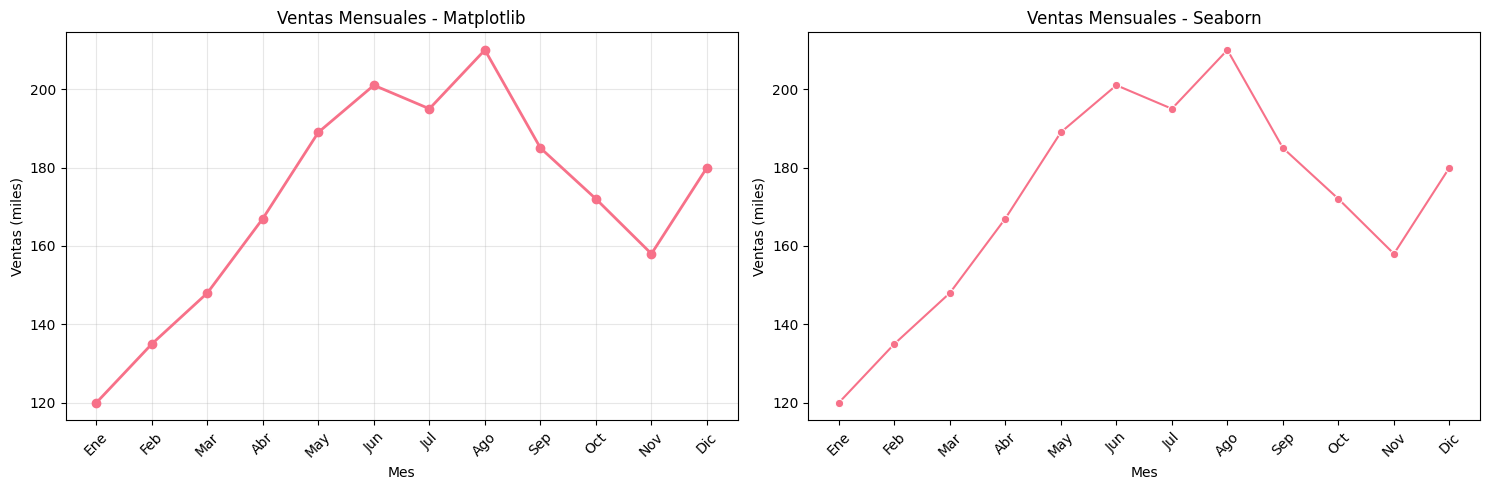

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Matplotlib
ax1.plot(meses, ventas, marker='o', linewidth=2, markersize=6)
ax1.set_title('Ventas Mensuales - Matplotlib')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Ventas (miles)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Seaborn
sns.lineplot(x=meses, y=ventas, marker='o', ax=ax2)
ax2.set_title('Ventas Mensuales - Seaborn')
ax2.set_xlabel('Mes')
ax2.set_ylabel('Ventas (miles)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Gráficos de Barras

**Cuándo usar**: Para comparar categorías discretas.

**Casos típicos**:
- Ventas por región
- Cantidad de productos por categoría
- Resultados de encuestas
- Rankings

In [48]:
productos.head()

,producto,ventas_q1,ventas_q2,ventas_q3,ventas_q4
0,A,23,34,28,31
1,B,45,52,48,55
2,C,56,61,59,64
3,D,78,85,82,88
4,E,32,28,35,38


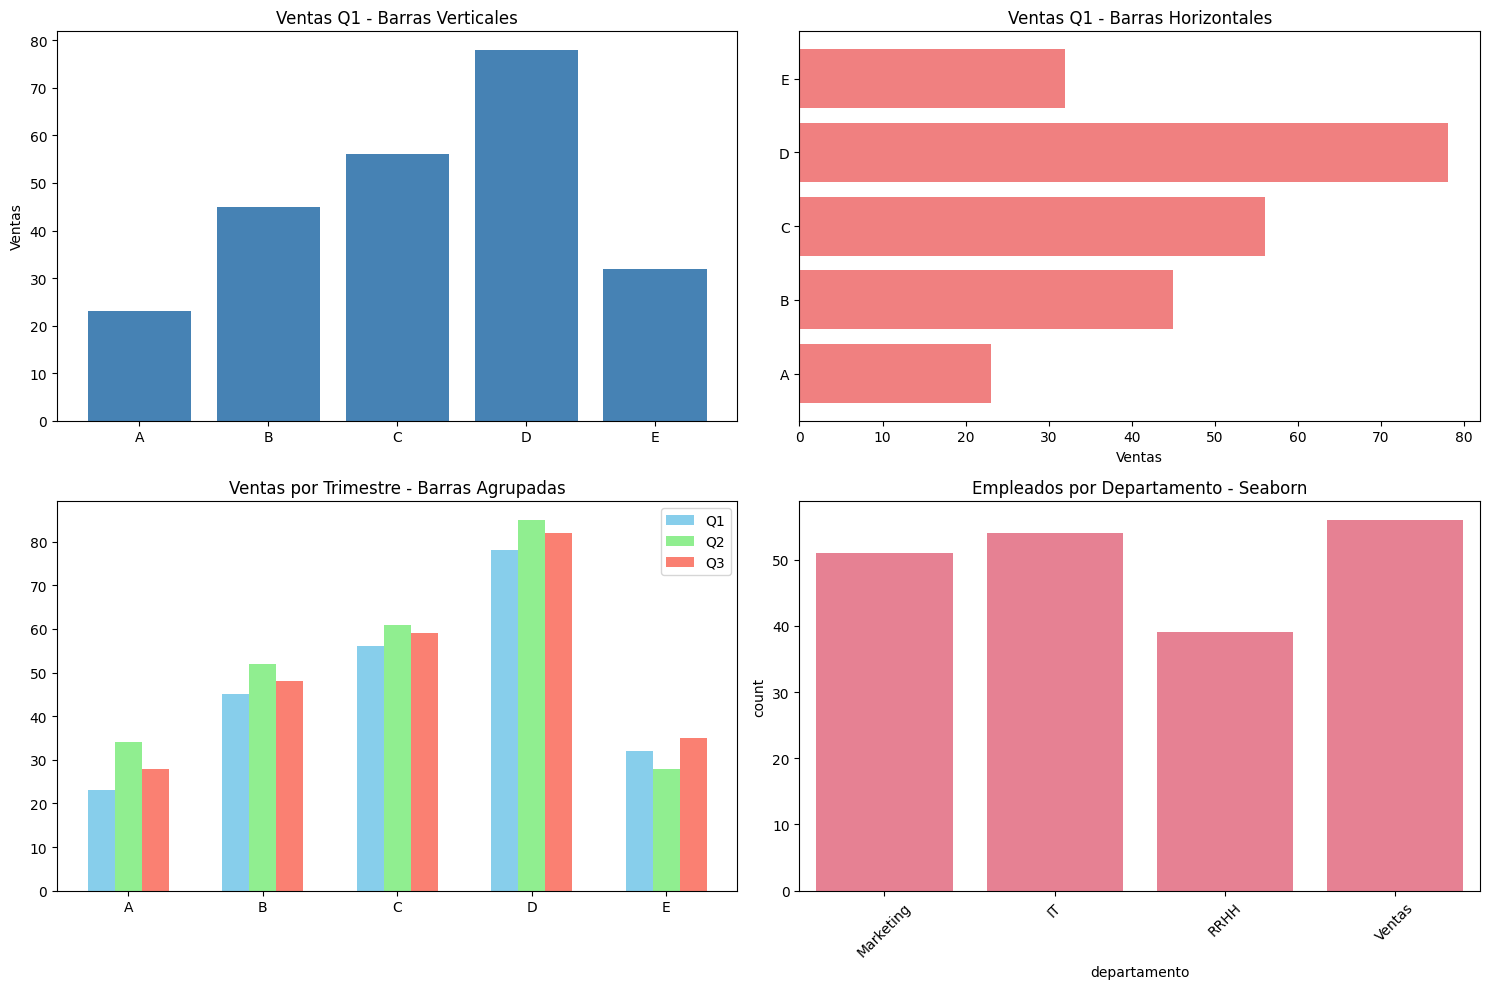

In [49]:
# Gráficos de barras
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Barras verticales - Matplotlib
ax1.bar(productos['producto'], productos['ventas_q1'], color='steelblue')
ax1.set_title('Ventas Q1 - Barras Verticales')
ax1.set_ylabel('Ventas')

# Barras horizontales - Matplotlib
ax2.barh(productos['producto'], productos['ventas_q1'], color='lightcoral')
ax2.set_title('Ventas Q1 - Barras Horizontales')
ax2.set_xlabel('Ventas')

# Barras agrupadas
x = np.arange(len(productos['producto']))
width = 0.2
ax3.bar(x - width, productos['ventas_q1'], width, label='Q1', color='skyblue')
ax3.bar(x, productos['ventas_q2'], width, label='Q2', color='lightgreen')
ax3.bar(x + width, productos['ventas_q3'], width, label='Q3', color='salmon')
ax3.set_title('Ventas por Trimestre - Barras Agrupadas')
ax3.set_xticks(x)
ax3.set_xticklabels(productos['producto'])
ax3.legend()

# Seaborn countplot
sns.countplot(data=empleados, x='departamento', ax=ax4)
ax4.set_title('Empleados por Departamento - Seaborn')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Histogramas

**Cuándo usar**: Para mostrar la distribución de una variable numérica continua.

**Casos típicos**:
- Distribución de edades
- Distribución de salarios
- Notas de exámenes
- Tiempos de respuesta

In [50]:
empleados.head()

,edad,salario,departamento,experiencia
0,39.967142,55366.810405,Marketing,1
1,33.617357,58411.767896,Marketing,12
2,41.476885,66245.768648,IT,13
3,50.230299,65807.030781,IT,18
4,32.658466,29334.959481,RRHH,6


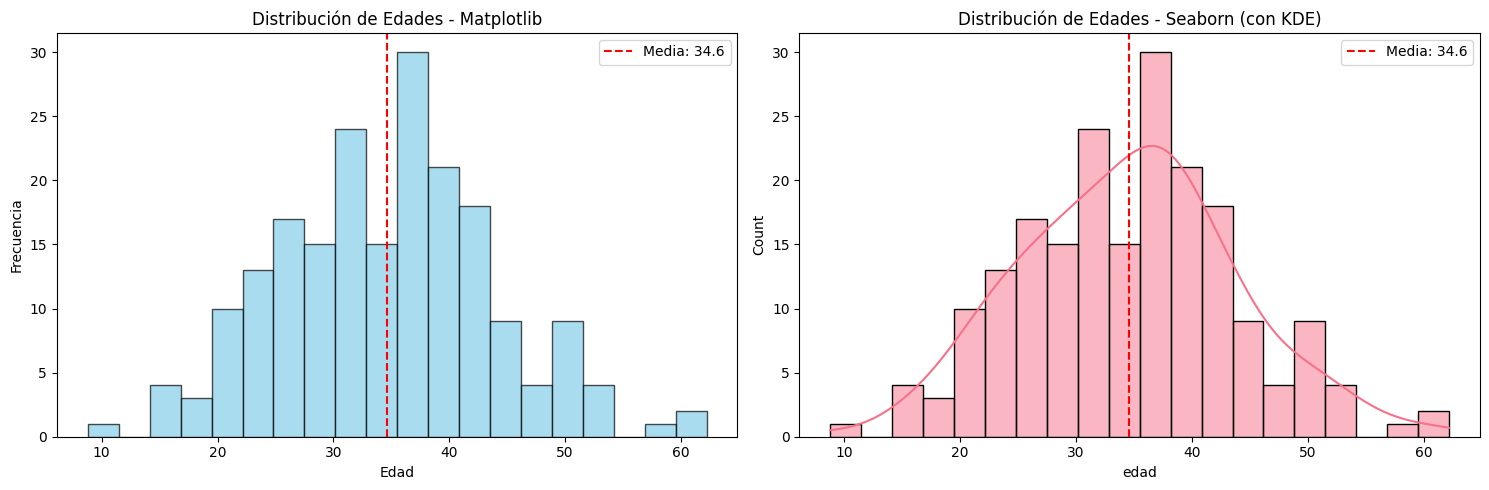

In [51]:
# Histogramas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Matplotlib
ax1.hist(empleados['edad'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
ax1.set_title('Distribución de Edades - Matplotlib')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Frecuencia')
ax1.axvline(empleados['edad'].mean(), color='red', linestyle='--', label=f'Media: {empleados["edad"].mean():.1f}')
ax1.legend()

# Seaborn
sns.histplot(data=empleados, x='edad', bins=20, kde=True, ax=ax2)
ax2.set_title('Distribución de Edades - Seaborn (con KDE)')
ax2.axvline(empleados['edad'].mean(), color='red', linestyle='--', label=f'Media: {empleados["edad"].mean():.1f}')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Gráficos de Dispersión (Scatter Plot)

**Cuándo usar**: Para mostrar la relación entre dos variables numéricas.

**Casos típicos**:
- Relación entre edad y salario
- Altura vs peso
- Precio vs demanda
- Experiencia vs productividad

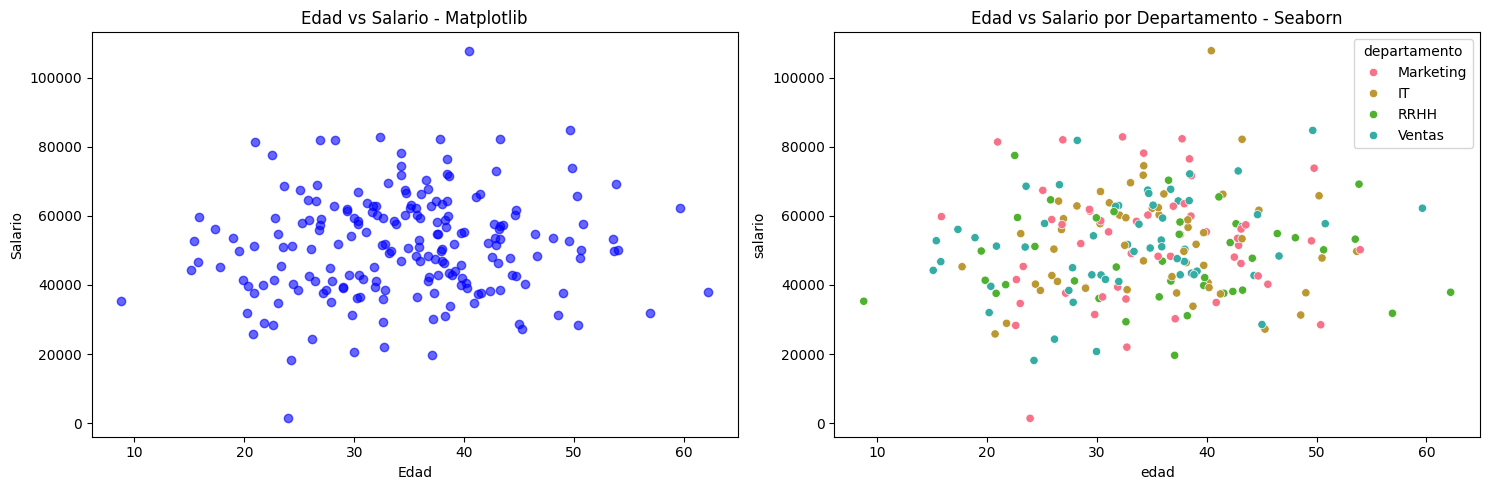

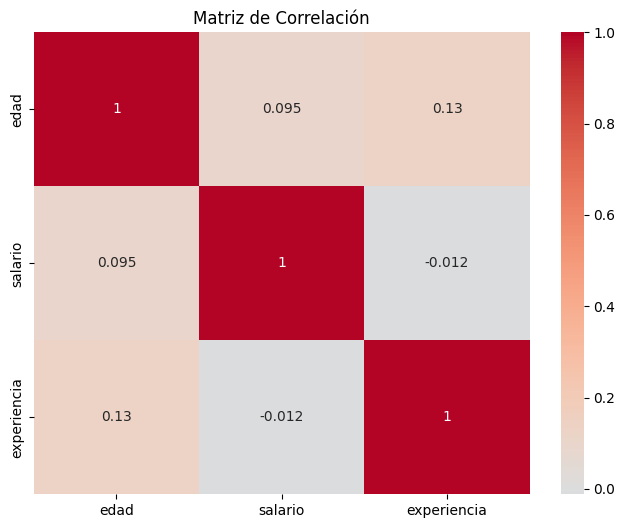

In [52]:
# Gráficos de dispersión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Matplotlib básico
ax1.scatter(empleados['edad'], empleados['salario'], alpha=0.6, color='blue')
ax1.set_title('Edad vs Salario - Matplotlib')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Salario')

# Seaborn con categorías
sns.scatterplot(data=empleados, x='edad', y='salario', hue='departamento', ax=ax2)
ax2.set_title('Edad vs Salario por Departamento - Seaborn')

plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(8, 6))
correlacion = empleados[['edad', 'salario', 'experiencia']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

## 5. Box Plots (Diagramas de Caja)

**Cuándo usar**: Para mostrar la distribución, mediana, cuartiles y valores atípicos.

**Casos típicos**:
- Comparar distribuciones entre grupos
- Identificar outliers
- Analizar la dispersión de datos
- Comparar rendimiento por categorías

/tmp/ipykernel_159620/3025318734.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(box_data, labels=empleados['departamento'].unique())


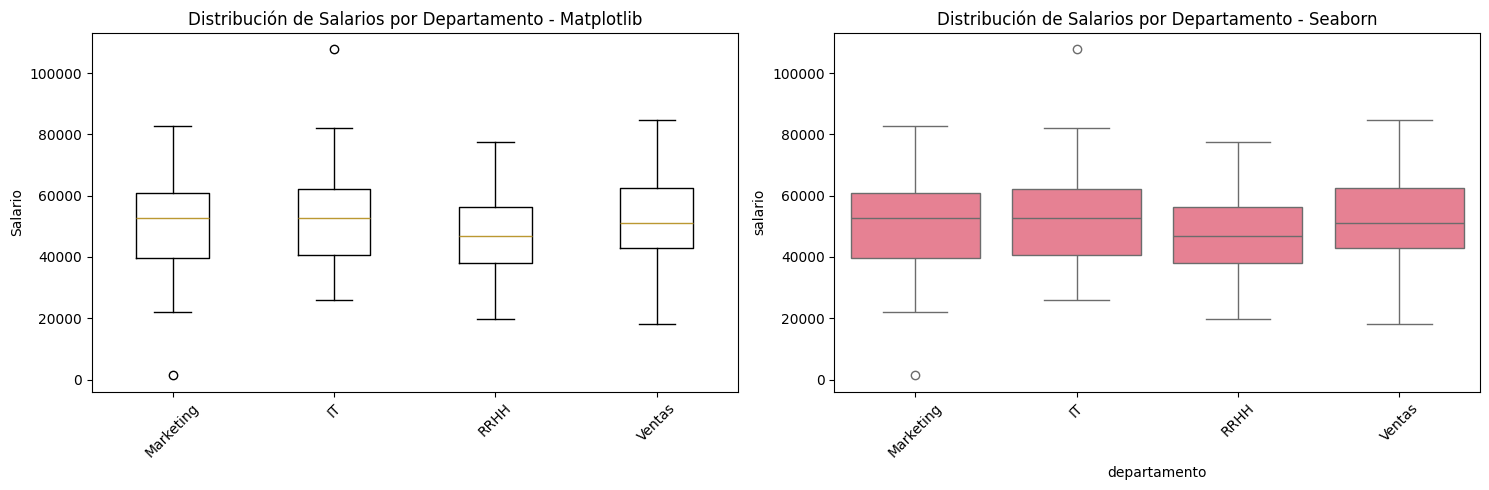

In [53]:
# Box plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Matplotlib
box_data = [empleados[empleados['departamento'] == dept]['salario'] for dept in empleados['departamento'].unique()]
ax1.boxplot(box_data, labels=empleados['departamento'].unique())
ax1.set_title('Distribución de Salarios por Departamento - Matplotlib')
ax1.set_ylabel('Salario')
ax1.tick_params(axis='x', rotation=45)

# Seaborn
sns.boxplot(data=empleados, x='departamento', y='salario', ax=ax2)
ax2.set_title('Distribución de Salarios por Departamento - Seaborn')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Gráficos de Pastel (Pie Charts)

**Cuándo usar**: Para mostrar proporciones de un total (usar con moderación).

**Casos típicos**:
- Market share
- Distribución de presupuesto
- Composición de una muestra
- Resultados de votaciones

**Nota**: Evitar con más de 5-6 categorías.

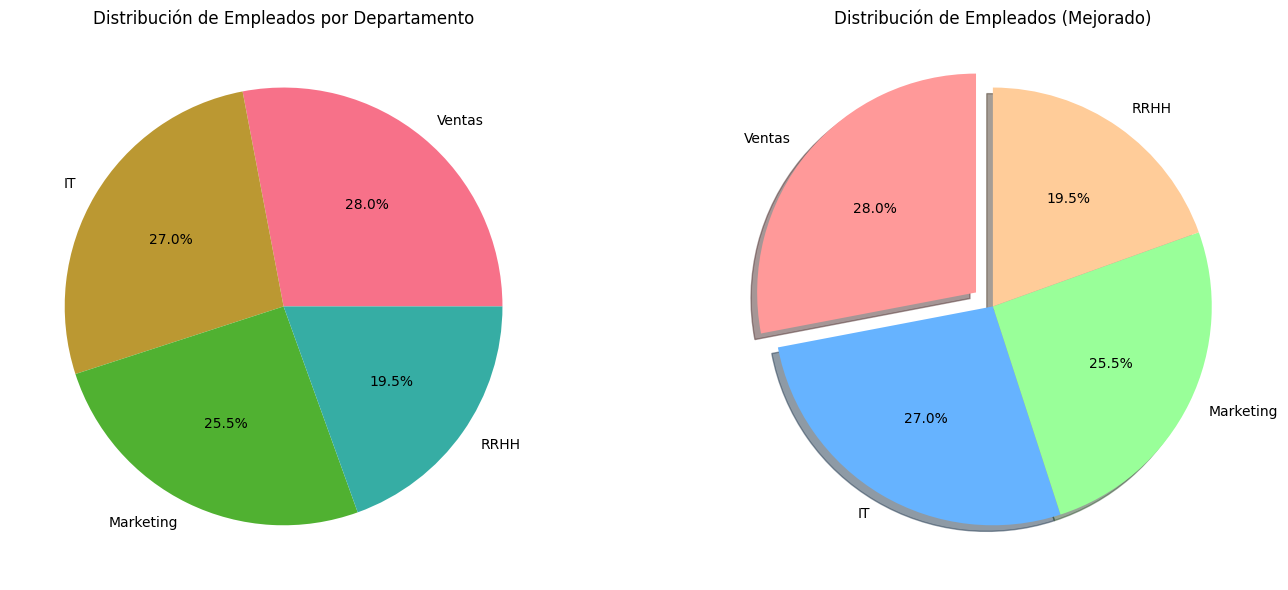

In [54]:
# Gráficos de pastel
departamentos_count = empleados['departamento'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Básico
ax1.pie(departamentos_count.values, labels=departamentos_count.index, autopct='%1.1f%%')
ax1.set_title('Distribución de Empleados por Departamento')

# Con explosión y colores personalizados
explode = (0.1, 0, 0, 0)  # explotar la primera porción
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
ax2.pie(departamentos_count.values, 
        labels=departamentos_count.index, 
        autopct='%1.1f%%',
        explode=explode,
        colors=colors,
        shadow=True,
        startangle=90)
ax2.set_title('Distribución de Empleados (Mejorado)')

plt.tight_layout()
plt.show()

## 7. Subplots y Layouts Avanzados

**Cuándo usar**: Para mostrar múltiples gráficos relacionados en una sola figura.

**Casos típicos**:
- Comparar diferentes métricas
- Mostrar diferentes vistas de los mismos datos
- Dashboards
- Análisis exploratorio

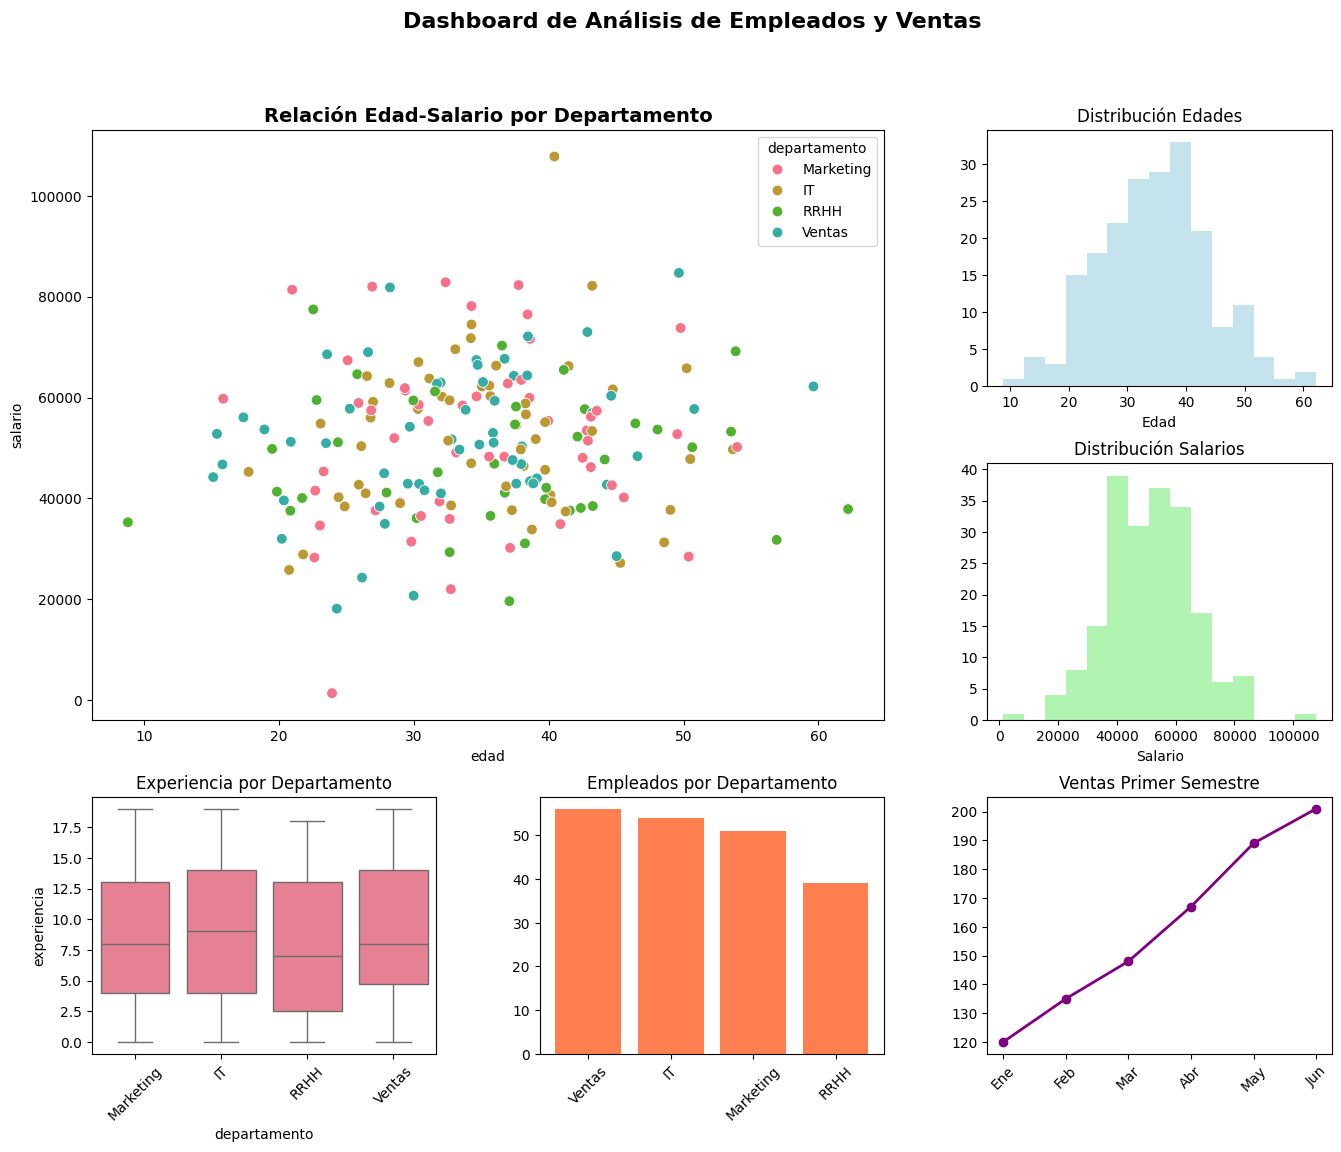

In [55]:
# Layout complejo con múltiples subplots
fig = plt.figure(figsize=(16, 12))

# Definir grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Gráfico principal (ocupa 2x2)
ax_main = fig.add_subplot(gs[0:2, 0:2])
sns.scatterplot(data=empleados, x='edad', y='salario', hue='departamento', s=60, ax=ax_main)
ax_main.set_title('Relación Edad-Salario por Departamento', fontsize=14, fontweight='bold')

# Histograma de edades
ax_hist_edad = fig.add_subplot(gs[0, 2])
ax_hist_edad.hist(empleados['edad'], bins=15, color='lightblue', alpha=0.7)
ax_hist_edad.set_title('Distribución Edades')
ax_hist_edad.set_xlabel('Edad')

# Histograma de salarios
ax_hist_salario = fig.add_subplot(gs[1, 2])
ax_hist_salario.hist(empleados['salario'], bins=15, color='lightgreen', alpha=0.7)
ax_hist_salario.set_title('Distribución Salarios')
ax_hist_salario.set_xlabel('Salario')

# Box plot
ax_box = fig.add_subplot(gs[2, 0])
sns.boxplot(data=empleados, x='departamento', y='experiencia', ax=ax_box)
ax_box.set_title('Experiencia por Departamento')
ax_box.tick_params(axis='x', rotation=45)

# Gráfico de barras
ax_bar = fig.add_subplot(gs[2, 1])
dept_counts = empleados['departamento'].value_counts()
ax_bar.bar(dept_counts.index, dept_counts.values, color='coral')
ax_bar.set_title('Empleados por Departamento')
ax_bar.tick_params(axis='x', rotation=45)

# Gráfico de línea
ax_line = fig.add_subplot(gs[2, 2])
ax_line.plot(meses[:6], ventas[:6], marker='o', color='purple', linewidth=2)
ax_line.set_title('Ventas Primer Semestre')
ax_line.tick_params(axis='x', rotation=45)

plt.suptitle('Dashboard de Análisis de Empleados y Ventas', fontsize=16, fontweight='bold')
plt.show()

## 8. Personalización Avanzada

### Estilos y Temas
Seaborn ofrece varios estilos predefinidos que mejoran la apariencia de los gráficos.

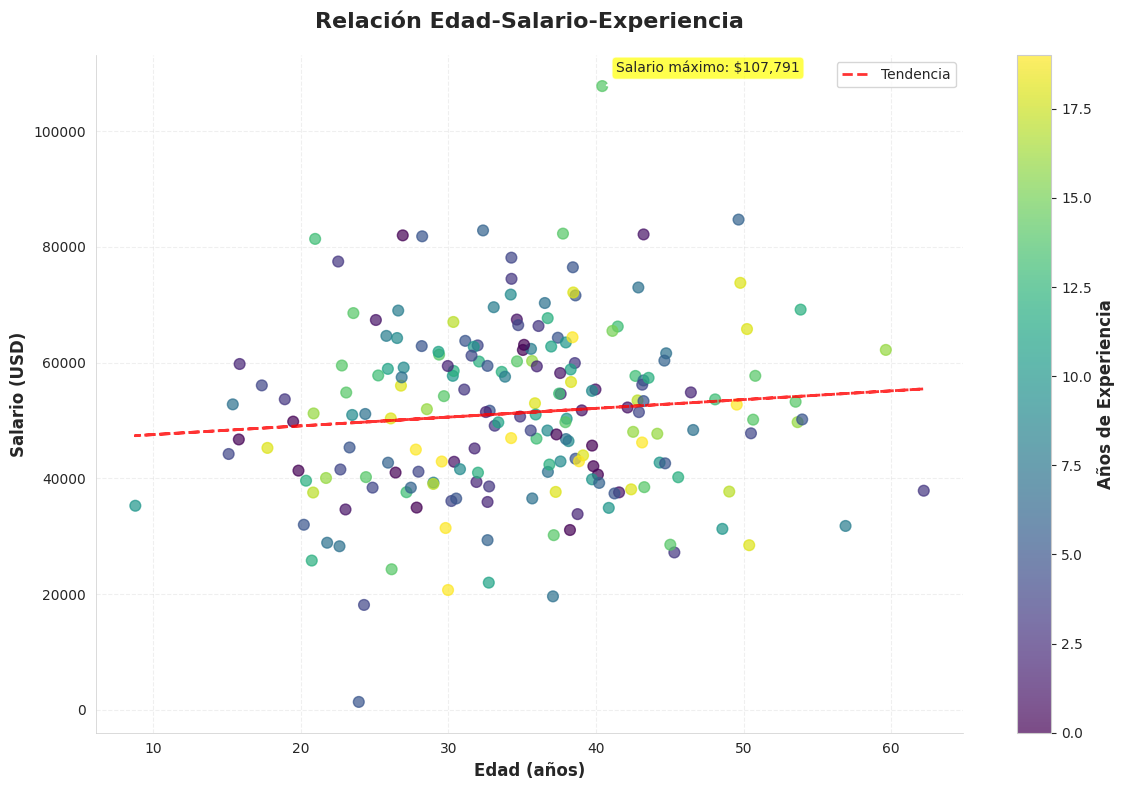

In [57]:
# Personalización avanzada con matplotlib
fig, ax = plt.subplots(figsize=(12, 8))

# Crear gráfico base
scatter = ax.scatter(empleados['edad'], empleados['salario'], 
                    c=empleados['experiencia'], s=60, alpha=0.7, cmap='viridis')

# Personalizar título y etiquetas
ax.set_title('Relación Edad-Salario-Experiencia', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
ax.set_ylabel('Salario (USD)', fontsize=12, fontweight='bold')

# Agregar colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Años de Experiencia', fontsize=12, fontweight='bold')

# Personalizar grid
ax.grid(True, alpha=0.3, linestyle='--')

# Personalizar spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Agregar línea de tendencia
z = np.polyfit(empleados['edad'], empleados['salario'], 1)
p = np.poly1d(z)
ax.plot(empleados['edad'], p(empleados['edad']), "r--", alpha=0.8, linewidth=2, label='Tendencia')
ax.legend()

# Agregar anotaciones
max_salario_idx = empleados['salario'].idxmax()
ax.annotate(f'Salario máximo: ${empleados.loc[max_salario_idx, "salario"]:,.0f}',
            xy=(empleados.loc[max_salario_idx, 'edad'], empleados.loc[max_salario_idx, 'salario']),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

## 9. Mejores Prácticas y Recomendaciones

### Selección del Gráfico Correcto

| Tipo de Datos | Gráfico Recomendado | Cuándo NO usar |
|---------------|-------------------|----------------|
| Una variable categórica | Barras, Pastel | Pastel con >6 categorías |
| Una variable numérica | Histograma, Box plot | Pastel |
| Dos variables numéricas | Dispersión, Línea | Barras |
| Categórica + Numérica | Box plot, Barras | Línea |
| Series temporales | Línea, Área | Barras, Pastel |
| Comparar distribuciones | Box plot, Violin | Histogramas superpuestos |

### Principios de Diseño

1. **Simplicidad**: Evitar elementos innecesarios
2. **Claridad**: Títulos, etiquetas y leyendas claras
3. **Consistencia**: Colores y estilos coherentes
4. **Accesibilidad**: Colores que funcionen para daltonismo
5. **Contexto**: Incluir información necesaria para interpretación

### Errores Comunes a Evitar

- Gráficos 3D innecesarios
- Demasiados colores
- Escalas truncadas o engañosas
- Texto demasiado pequeño
- Falta de títulos o etiquetas

/tmp/ipykernel_159620/1982334398.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax3.scatter(dept_data['edad'], dept_data['salario'],


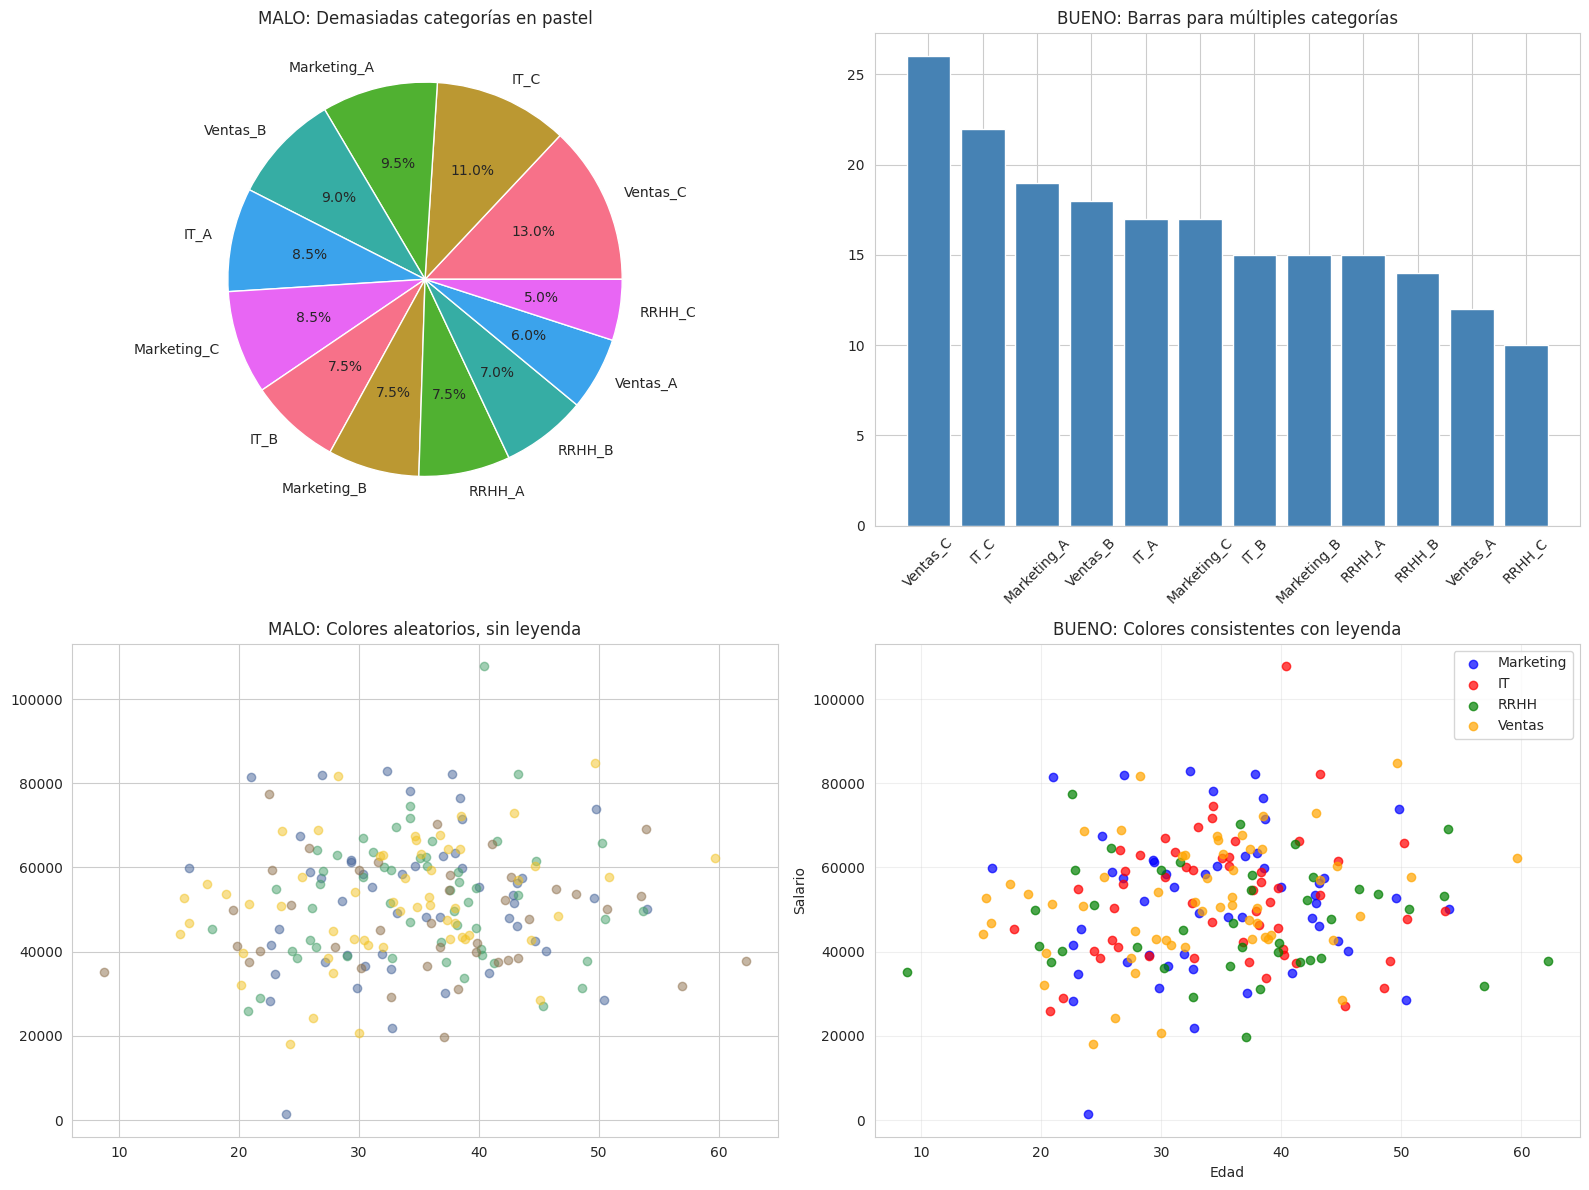

In [58]:
# Ejemplo de buenas vs malas prácticas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# MALO: Gráfico de pastel con demasiadas categorías
empleados_extended = empleados.copy()
empleados_extended['sub_dept'] = empleados_extended['departamento'] + '_' + np.random.choice(['A', 'B', 'C'], len(empleados_extended))
sub_dept_counts = empleados_extended['sub_dept'].value_counts()
ax1.pie(sub_dept_counts.values, labels=sub_dept_counts.index, autopct='%1.1f%%')
ax1.set_title('MALO: Demasiadas categorías en pastel')

# BUENO: Gráfico de barras para múltiples categorías
ax2.bar(sub_dept_counts.index, sub_dept_counts.values, color='steelblue')
ax2.set_title('BUENO: Barras para múltiples categorías')
ax2.tick_params(axis='x', rotation=45)

# MALO: Colores confusos y sin leyenda
for i, dept in enumerate(empleados['departamento'].unique()):
    dept_data = empleados[empleados['departamento'] == dept]
    ax3.scatter(dept_data['edad'], dept_data['salario'], 
               c=np.random.rand(3,), alpha=0.5)
ax3.set_title('MALO: Colores aleatorios, sin leyenda')

# BUENO: Colores consistentes con leyenda
colors = ['blue', 'red', 'green', 'orange']
for i, dept in enumerate(empleados['departamento'].unique()):
    dept_data = empleados[empleados['departamento'] == dept]
    ax4.scatter(dept_data['edad'], dept_data['salario'], 
               c=colors[i], label=dept, alpha=0.7)
ax4.set_title('BUENO: Colores consistentes con leyenda')
ax4.set_xlabel('Edad')
ax4.set_ylabel('Salario')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ejercicios Prácticos

A continuación encontrarás 5 ejercicios con diferentes datasets sintéticos para practicar los conceptos aprendidos. Cada ejercicio incluye preguntas específicas que debes responder utilizando visualizaciones apropiadas.

In [59]:
# CREACIÓN DE DATASETS PARA EJERCICIOS
np.random.seed(123)

# Dataset 1: E-commerce
fechas = pd.date_range('2023-01-01', '2023-12-31', freq='D')
ecommerce = pd.DataFrame({
    'fecha': fechas,
    'visitas': np.random.poisson(1000, len(fechas)) + np.sin(np.arange(len(fechas)) * 2 * np.pi / 365) * 200,
    'ventas': np.random.poisson(50, len(fechas)) + np.sin(np.arange(len(fechas)) * 2 * np.pi / 365) * 10,
    'ingresos': np.random.normal(2500, 500, len(fechas)),
    'categoria_principal': np.random.choice(['Electrónicos', 'Ropa', 'Hogar', 'Deportes'], len(fechas))
})

# Dataset 2: Estudiantes universitarios
n_estudiantes = 500
estudiantes = pd.DataFrame({
    'carrera': np.random.choice(['Ingeniería', 'Medicina', 'Derecho', 'Economía', 'Arte'], n_estudiantes),
    'promedio': np.random.normal(7.5, 1.2, n_estudiantes),
    'horas_estudio': np.random.gamma(2, 2, n_estudiantes),
    'año': np.random.choice([1, 2, 3, 4, 5], n_estudiantes),
    'edad': np.random.normal(21, 2.5, n_estudiantes),
    'beca': np.random.choice(['Sí', 'No'], n_estudiantes, p=[0.3, 0.7])
})
# Ajustar promedio para que sea realista
estudiantes['promedio'] = np.clip(estudiantes['promedio'], 4, 10)
estudiantes['edad'] = np.clip(estudiantes['edad'], 17, 30).astype(int)
estudiantes['horas_estudio'] = np.clip(estudiantes['horas_estudio'], 1, 15)

# Dataset 3: Ventas inmobiliarias
n_propiedades = 300
inmobiliarias = pd.DataFrame({
    'precio': np.random.lognormal(12, 0.5, n_propiedades),
    'metros_cuadrados': np.random.normal(120, 40, n_propiedades),
    'habitaciones': np.random.choice([1, 2, 3, 4, 5], n_propiedades, p=[0.1, 0.3, 0.4, 0.15, 0.05]),
    'zona': np.random.choice(['Centro', 'Norte', 'Sur', 'Este', 'Oeste'], n_propiedades),
    'antigüedad': np.random.randint(0, 50, n_propiedades),
    'tipo': np.random.choice(['Departamento', 'Casa', 'PH'], n_propiedades, p=[0.6, 0.3, 0.1])
})
inmobiliarias['metros_cuadrados'] = np.clip(inmobiliarias['metros_cuadrados'], 30, 300)
inmobiliarias['precio'] = inmobiliarias['precio'] * (1 + inmobiliarias['metros_cuadrados']/500) * (1 - inmobiliarias['antigüedad']/100)

# Dataset 4: Datos de salud
n_pacientes = 400
salud = pd.DataFrame({
    'edad': np.random.randint(18, 80, n_pacientes),
    'peso': np.random.normal(70, 15, n_pacientes),
    'altura': np.random.normal(170, 10, n_pacientes),
    'presion_sistolica': np.random.normal(120, 20, n_pacientes),
    'colesterol': np.random.normal(200, 40, n_pacientes),
    'ejercicio_semanal': np.random.exponential(2, n_pacientes),
    'fumador': np.random.choice(['Sí', 'No'], n_pacientes, p=[0.25, 0.75]),
    'genero': np.random.choice(['M', 'F'], n_pacientes)
})
# Ajustar valores realistas
salud['peso'] = np.clip(salud['peso'], 40, 150)
salud['altura'] = np.clip(salud['altura'], 140, 200)
salud['ejercicio_semanal'] = np.clip(salud['ejercicio_semanal'], 0, 10)
salud['imc'] = salud['peso'] / ((salud['altura']/100) ** 2)

# Dataset 5: Empresa tecnológica
n_empleados_tech = 250
tech_company = pd.DataFrame({
    'puesto': np.random.choice(['Developer', 'Data Scientist', 'Product Manager', 'Designer', 'DevOps'], n_empleados_tech),
    'salario_usd': np.random.normal(80000, 25000, n_empleados_tech),
    'años_experiencia': np.random.exponential(3, n_empleados_tech),
    'satisfaccion': np.random.normal(7, 1.5, n_empleados_tech),
    'trabajo_remoto': np.random.choice(['Completo', 'Híbrido', 'Presencial'], n_empleados_tech, p=[0.4, 0.4, 0.2]),
    'educacion': np.random.choice(['Universitario', 'Posgrado', 'Autodidacta'], n_empleados_tech, p=[0.5, 0.35, 0.15]),
    'proyectos_completados': np.random.poisson(8, n_empleados_tech)
})
# Ajustar valores
tech_company['años_experiencia'] = np.clip(tech_company['años_experiencia'], 0, 20)
tech_company['satisfaccion'] = np.clip(tech_company['satisfaccion'], 1, 10)
tech_company['salario_usd'] = np.clip(tech_company['salario_usd'], 40000, 200000)

print("Datasets creados exitosamente para los ejercicios:")
print(f"1. E-commerce: {len(ecommerce)} registros")
print(f"2. Estudiantes: {len(estudiantes)} registros") 
print(f"3. Inmobiliarias: {len(inmobiliarias)} registros")
print(f"4. Salud: {len(salud)} registros")
print(f"5. Tech Company: {len(tech_company)} registros")

Datasets creados exitosamente para los ejercicios:
1. E-commerce: 365 registros
2. Estudiantes: 500 registros
3. Inmobiliarias: 300 registros
4. Salud: 400 registros
5. Tech Company: 250 registros


### Ejercicio 1: Análisis de E-commerce

**Dataset**: Datos diarios de un e-commerce durante 2023

**Preguntas a resolver**:
1. ¿Cómo evolucionaron las visitas y ventas a lo largo del año?
2. ¿Existe correlación entre visitas, ventas e ingresos?
3. ¿Qué categoría genera más ventas?
4. ¿Hay patrones estacionales en los datos?

**Tu turno**: Crea al menos 3 visualizaciones diferentes para responder estas preguntas.

In [60]:
ecommerce.head()

,fecha,visitas,ventas,ingresos,categoria_principal
0,2023-01-01,1018.000000,55.000000,2933.853126,Deportes
1,2023-01-02,976.442671,52.172134,2784.920257,Deportes
2,2023-01-03,1027.884322,44.344216,2386.693463,Hogar
3,2023-01-04,1008.323933,44.516197,2002.386077,Deportes
4,2023-01-05,998.760485,48.688024,2831.739628,Electrónicos


In [61]:
# EJERCICIO 1: E-COMMERCE
# Completa aquí tu análisis del dataset de e-commerce

# Pista 1: Para análisis temporal, agrupa por mes
ecommerce['mes'] = ecommerce['fecha'].dt.month
ventas_mensuales = ecommerce.groupby('mes').agg({
    'visitas': 'mean',
    'ventas': 'sum',
    'ingresos': 'sum'
}).reset_index()

# Tu código aquí...



### Ejercicio 2: Análisis Académico

**Dataset**: Datos de 500 estudiantes universitarios

**Preguntas a resolver**:
1. ¿Cómo se distribuyen los promedios por carrera?
2. ¿Existe relación entre horas de estudio y promedio?
3. ¿Los estudiantes con beca tienen mejores promedios?
4. ¿Cómo varía el rendimiento por año de carrera?

**Tu turno**: Utiliza box plots, scatter plots e histogramas para el análisis.

In [62]:
# EJERCICIO 2: ESTUDIANTES UNIVERSITARIOS
# Completa aquí tu análisis del dataset de estudiantes

# Pista: Explora las diferencias entre grupos
print("Resumen del dataset:")
print(estudiantes.describe())
print("\nDatos por carrera:")
print(estudiantes.groupby('carrera')['promedio'].describe())

# Tu código aquí...



Resumen del dataset:
         promedio  horas_estudio         año        edad
count  500.000000     500.000000  500.000000  500.000000
mean     7.504698       4.203585    3.196000   20.708000
std      1.141632       2.900432    1.426061    2.354958
min      4.029543       1.000000    1.000000   17.000000
25%      6.714117       1.947924    2.000000   19.000000
50%      7.475509       3.438252    3.000000   21.000000
75%      8.371896       5.655273    4.000000   22.000000
max     10.000000      15.000000    5.000000   27.000000

Datos por carrera:
            count      mean       std       min       25%       50%       75%  \
carrera                                                                         
Arte         75.0  7.551832  1.175626  4.611632  6.726504  7.426328  8.365832   
Derecho     117.0  7.676560  1.097338  4.029543  6.931279  7.781212  8.460782   
Economía    102.0  7.677551  1.203441  4.436188  6.656679  7.884477  8.533880   
Ingeniería  110.0  7.275901  1.183316  4.

### Ejercicio 3: Mercado Inmobiliario

**Dataset**: Propiedades en venta en diferentes zonas

**Preguntas a resolver**:
1. ¿Cómo se distribuyen los precios por zona?
2. ¿Qué factores influyen más en el precio? (metros cuadrados, habitaciones, antigüedad)
3. ¿Hay diferencias de precio entre tipos de propiedad?
4. ¿Existe relación entre antigüedad y precio?

**Tu turno**: Combina gráficos de barras, scatter plots y box plots para tu análisis.

In [63]:
# EJERCICIO 3: INMOBILIARIAS
# Completa aquí tu análisis del dataset inmobiliario

# Pista: Calcula precio por metro cuadrado para mejor análisis
inmobiliarias['precio_m2'] = inmobiliarias['precio'] / inmobiliarias['metros_cuadrados']

print("Estadísticas de precios por zona:")
print(inmobiliarias.groupby('zona')['precio'].describe())

# Tu código aquí...



Estadísticas de precios por zona:
        count           mean            std           min            25%  \
zona                                                                       
Centro   67.0  171265.294718   97234.153932  49849.898421   95150.953309   
Este     57.0  172976.476183   98503.934716  47215.350434   91712.952821   
Norte    57.0  160866.167529   96490.671229  39796.668340   86512.013987   
Oeste    53.0  181268.560078   93126.649053  56956.702678  109785.917897   
Sur      66.0  185220.078628  112902.901164  21656.429364   93178.617453   

                  50%            75%            max  
zona                                                 
Centro  149628.076840  219155.851017  519323.838806  
Este    159715.530315  219970.033952  457330.393025  
Norte   123699.043753  200675.870531  408370.581038  
Oeste   170823.096693  233500.716165  455489.427391  
Sur     153770.851112  248302.147922  498866.054052  


### Ejercicio 4: Datos de Salud

**Dataset**: Información médica de 400 pacientes

**Preguntas a resolver**:
1. ¿Cómo se distribuye el IMC en la población?
2. ¿Existe relación entre edad y presión sistólica?
3. ¿Los fumadores tienen diferentes niveles de colesterol?
4. ¿Cómo se relaciona el ejercicio con los indicadores de salud?

**Tu turno**: Usa histogramas, scatter plots y análisis por grupos para responder.

In [64]:
# EJERCICIO 4: DATOS DE SALUD
# Completa aquí tu análisis del dataset de salud

# Pista: Categoriza el IMC para mejor análisis
def categorizar_imc(imc):
    if imc < 18.5:
        return 'Bajo peso'
    elif imc < 25:
        return 'Normal'
    elif imc < 30:
        return 'Sobrepeso'
    else:
        return 'Obesidad'

salud['categoria_imc'] = salud['imc'].apply(categorizar_imc)

print("Distribución de categorías de IMC:")
print(salud['categoria_imc'].value_counts())

# Tu código aquí...



Distribución de categorías de IMC:
categoria_imc
Normal       163
Sobrepeso    110
Bajo peso     67
Obesidad      60
Name: count, dtype: int64


### Ejercicio 5: Empresa Tecnológica

**Dataset**: Empleados de una empresa tech

**Preguntas a resolver**:
1. ¿Cómo varían los salarios por puesto y experiencia?
2. ¿Existe relación entre satisfacción laboral y modalidad de trabajo?
3. ¿El nivel educativo influye en el salario?
4. ¿Los empleados más experimentados completan más proyectos?

**Tu turno**: Crea un dashboard completo combinando múltiples visualizaciones.

In [65]:
# EJERCICIO 5: EMPRESA TECNOLÓGICA
# Completa aquí tu análisis del dataset tech

# Pista: Explora relaciones multivariadas
print("Salarios promedio por puesto:")
print(tech_company.groupby('puesto')['salario_usd'].mean().sort_values(ascending=False))

print("\nSatisfacción promedio por modalidad:")
print(tech_company.groupby('trabajo_remoto')['satisfaccion'].mean())

# Tu código aquí...



Salarios promedio por puesto:
puesto
Product Manager    86157.923721
DevOps             82740.232404
Designer           82531.214323
Data Scientist     81270.476039
Developer          78596.989144
Name: salario_usd, dtype: float64

Satisfacción promedio por modalidad:
trabajo_remoto
Completo      7.021699
Híbrido       6.973400
Presencial    6.872815
Name: satisfaccion, dtype: float64
